# Complete Finance Trends 2020–2025 Machine Learning Project

## Project Title
### Predicting Investment Avenues Using Financial Behaviour Data

# Dataset

* Finance Trends 2020–2025
* Dataset Source: Kaggle
* Dataset Link: https://www.kaggle.com/datasets/ayeshasiddiqa123/finance-trends-2020-2025

# Task Type

Supervised Learning — Classification

# 1. Import Required Libraries

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

RANDOM_STATE = 42

os.makedirs("figures", exist_ok=True)
os.makedirs("tables", exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Load Dataset

In [3]:
file_path = "/kaggle/input/datasets/ayeshasiddiqa123/finance-trends-2020-2025/Finance_Trends.csv"

df_raw = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df_raw.shape)

display(df_raw.head())


Dataset loaded successfully.
Dataset shape: (12000, 24)


,gender,age,Investment_Avenues,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold,...,Duration,Invest_Monitor,Expect,Avenue,What are your savings objectives?,Reason_Equity,Reason_Mutual,Reason_Bonds,Reason_FD,Source
0,Male,29,Yes,2,4,7,5,3,1,6,...,Less than 1 year,Weekly,20%-30%,Public Provident Fund,Health Care,Dividend,Fund Diversification,Assured Returns,Fixed Returns,Newspapers and Magazines
1,Male,28,Yes,2,3,6,5,1,4,7,...,Less than 1 year,Weekly,30%-40%,Public Provident Fund,Retirement Plan,Capital Appreciation,Better Returns,Assured Returns,Risk Free,Television
2,Female,28,Yes,2,3,7,5,4,1,6,...,3-5 years,Daily,10%-20%,Mutual Fund,Health Care,Dividend,Better Returns,Assured Returns,Risk Free,Financial Consultants
3,Male,19,Yes,2,3,7,4,6,1,5,...,More than 5 years,Monthly,10%-20%,Equity,Retirement Plan,Capital Appreciation,Better Returns,Assured Returns,Risk Free,Newspapers and Magazines
4,Male,32,Yes,2,4,7,5,3,1,6,...,More than 5 years,Weekly,10%-20%,Public Provident Fund,Retirement Plan,Capital Appreciation,Better Returns,Assured Returns,Fixed Returns,Financial Consultants


# 3. Dataset Overview

In [4]:
print("Dataset information:")
display(df_raw.info())

print("\nMissing values:")
display(df_raw.isnull().sum())

print("\nDuplicate rows:", df_raw.duplicated().sum())

print("\nColumn names:")
display(pd.DataFrame({"Columns": df_raw.columns}))

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   gender                             12000 non-null  object
 1   age                                12000 non-null  int64 
 2   Investment_Avenues                 12000 non-null  object
 3   Mutual_Funds                       12000 non-null  int64 
 4   Equity_Market                      12000 non-null  int64 
 5   Debentures                         12000 non-null  int64 
 6   Government_Bonds                   12000 non-null  int64 
 7   Fixed_Deposits                     12000 non-null  int64 
 8   PPF                                12000 non-null  int64 
 9   Gold                               12000 non-null  int64 
 10  Stock_Marktet                      12000 non-null  object
 11  Factor                             12000 non-n

None


Missing values:


gender                               0
age                                  0
Investment_Avenues                   0
Mutual_Funds                         0
Equity_Market                        0
Debentures                           0
Government_Bonds                     0
Fixed_Deposits                       0
PPF                                  0
Gold                                 0
Stock_Marktet                        0
Factor                               0
Objective                            0
Purpose                              0
Duration                             0
Invest_Monitor                       0
Expect                               0
Avenue                               0
What are your savings objectives?    0
Reason_Equity                        0
Reason_Mutual                        0
Reason_Bonds                         0
Reason_FD                            0
Source                               0
dtype: int64


Duplicate rows: 1611

Column names:


,Columns
0,gender
1,age
2,Investment_Avenues
3,Mutual_Funds
4,Equity_Market
5,Debentures
6,Government_Bonds
7,Fixed_Deposits
8,PPF
9,Gold


# 4. Data Cleaning

In [5]:
def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )
    return df


def basic_cleaning(df):
    df = clean_column_names(df)
    df = df.drop_duplicates()

    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].astype(str).str.strip()
            df[col] = df[col].replace("nan", np.nan)

            if df[col].isna().sum() > 0:
                df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df[col] = df[col].fillna(df[col].median())

    return df


df = basic_cleaning(df_raw)

print("Cleaned dataset shape:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())

display(df.head())


Cleaned dataset shape: (10389, 24)
Remaining missing values: 0


,gender,age,Investment_Avenues,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold,...,Duration,Invest_Monitor,Expect,Avenue,What_are_your_savings_objectives?,Reason_Equity,Reason_Mutual,Reason_Bonds,Reason_FD,Source
0,Male,29,Yes,2,4,7,5,3,1,6,...,Less than 1 year,Weekly,20%-30%,Public Provident Fund,Health Care,Dividend,Fund Diversification,Assured Returns,Fixed Returns,Newspapers and Magazines
1,Male,28,Yes,2,3,6,5,1,4,7,...,Less than 1 year,Weekly,30%-40%,Public Provident Fund,Retirement Plan,Capital Appreciation,Better Returns,Assured Returns,Risk Free,Television
2,Female,28,Yes,2,3,7,5,4,1,6,...,3-5 years,Daily,10%-20%,Mutual Fund,Health Care,Dividend,Better Returns,Assured Returns,Risk Free,Financial Consultants
3,Male,19,Yes,2,3,7,4,6,1,5,...,More than 5 years,Monthly,10%-20%,Equity,Retirement Plan,Capital Appreciation,Better Returns,Assured Returns,Risk Free,Newspapers and Magazines
4,Male,32,Yes,2,4,7,5,3,1,6,...,More than 5 years,Weekly,10%-20%,Public Provident Fund,Retirement Plan,Capital Appreciation,Better Returns,Assured Returns,Fixed Returns,Financial Consultants


# 5. Target Variable Selection

In [6]:
def choose_target(df):
    possible_targets = [
        "Investment_Avenues",
        "Investment_Preference",
        "investment_avenues",
        "investment_preference",
        "Avenue",
        "Preferred_Investment"
    ]

    for col in possible_targets:
        if col in df.columns:
            return col

    object_cols = df.select_dtypes(include="object").columns.tolist()

    if object_cols:
        return object_cols[-1]

    return df.columns[-1]


target_col = choose_target(df)

print("Selected target variable:", target_col)

target_distribution = df[target_col].value_counts().reset_index()
target_distribution.columns = [target_col, "Count"]

display(target_distribution)

target_distribution.to_csv("tables/target_distribution.csv", index=False)


Selected target variable: Investment_Avenues


,Investment_Avenues,Count
0,Yes,9594
1,No,795


# 6. Exploratory Data Analysis

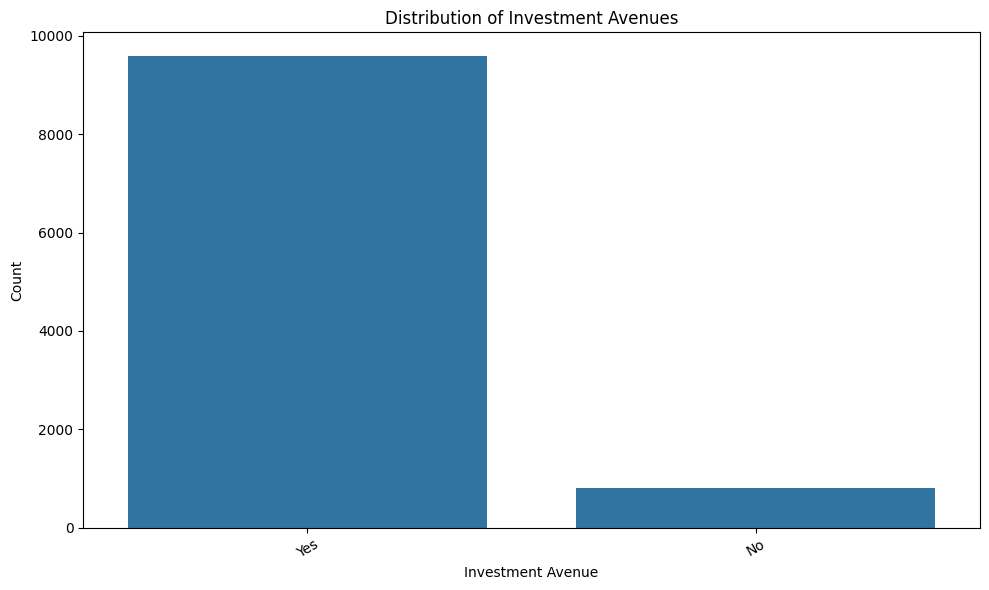

In [7]:
# Target distribution figure
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x=target_col,
    order=df[target_col].value_counts().index
)

plt.title("Distribution of Investment Avenues")
plt.xlabel("Investment Avenue")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("figures/target_distribution.pdf")
plt.show()

In [8]:
# Categorical feature summaries
categorical_cols = df.select_dtypes(include="object").columns.tolist()

eda_summary = []

for col in categorical_cols:
    eda_summary.append({
        "Column": col,
        "Unique_Values": df[col].nunique(),
        "Most_Common_Value": df[col].mode()[0],
        "Most_Common_Count": df[col].value_counts().iloc[0]
    })

eda_summary_df = pd.DataFrame(eda_summary)

display(eda_summary_df)

eda_summary_df.to_csv("tables/categorical_feature_summary.csv", index=False)


,Column,Unique_Values,Most_Common_Value,Most_Common_Count
0,gender,2,Male,6497
1,Investment_Avenues,2,Yes,9594
2,Stock_Marktet,2,Yes,9101
3,Factor,3,Returns,6441
4,Objective,3,Capital Appreciation,6753
5,Purpose,3,Wealth Creation,8321
6,Duration,4,3-5 years,2642
7,Invest_Monitor,3,Daily,3481
8,Expect,3,30%-40%,3512
9,Avenue,4,Fixed Deposits,2640


In [9]:
# Numeric feature summaries
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numeric_cols) > 0:
    numeric_summary = df[numeric_cols].describe().T
    display(numeric_summary)
    numeric_summary.to_csv("tables/numeric_feature_summary.csv")
else:
    print("No numeric columns found before encoding.")


,count,mean,std,min,25%,50%,75%,max
age,10389.0,27.791221,4.049299,18.0,25.0,28.0,31.0,38.0
Mutual_Funds,10389.0,2.539417,1.173983,1.0,2.0,2.0,3.0,7.0
Equity_Market,10389.0,3.462220,1.113609,1.0,3.0,4.0,4.0,6.0
Debentures,10389.0,5.774858,1.639613,1.0,5.0,7.0,7.0,7.0
Government_Bonds,10389.0,4.671383,1.337102,1.0,4.0,5.0,5.0,7.0
Fixed_Deposits,10389.0,3.561459,1.752440,1.0,3.0,4.0,5.0,7.0
PPF,10389.0,2.015882,1.588864,1.0,1.0,1.0,2.0,6.0
Gold,10389.0,5.974781,1.122090,2.0,6.0,6.0,7.0,7.0


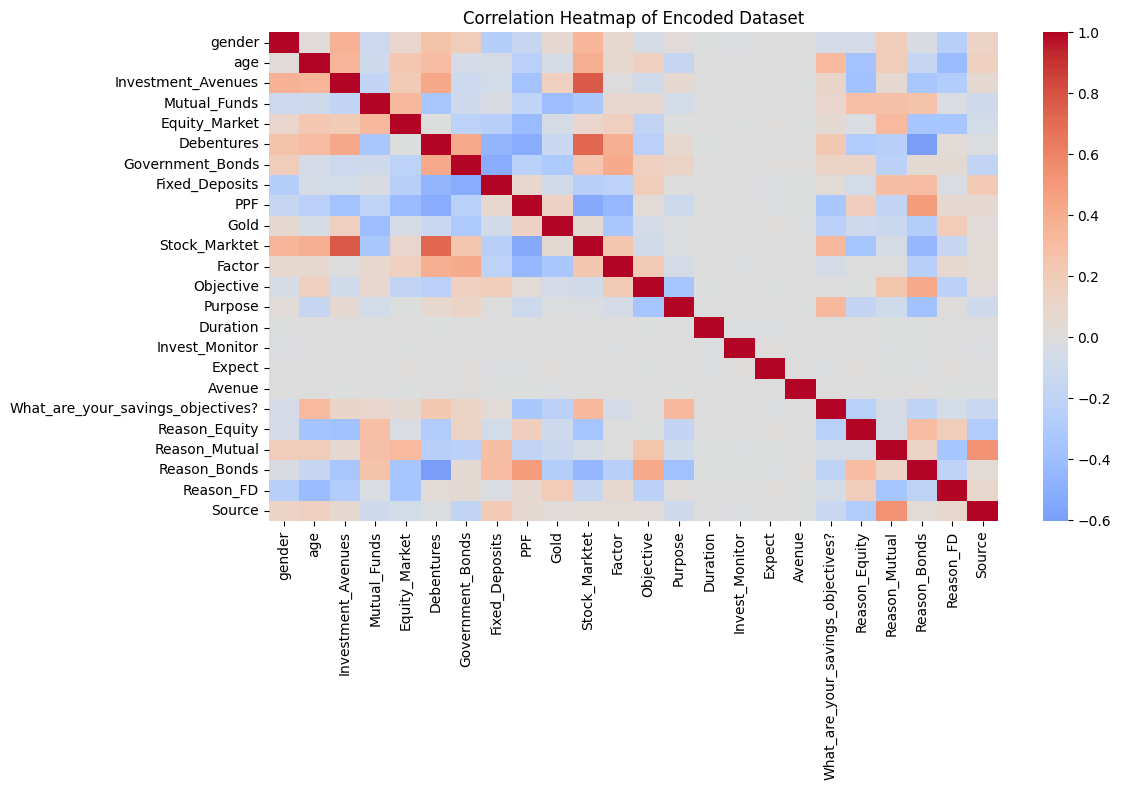

In [10]:
# Correlation heatmap after encoding
df_encoded_for_corr = df.copy()

for col in df_encoded_for_corr.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df_encoded_for_corr[col] = le.fit_transform(df_encoded_for_corr[col].astype(str))

corr = df_encoded_for_corr.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Encoded Dataset")
plt.tight_layout()

plt.savefig("figures/correlation_heatmap.pdf")
plt.show()

corr.to_csv("tables/correlation_matrix.csv")


# 7. Feature Encoding and ML Data Preparation

In [12]:
def prepare_numeric_ml_data(df, target_col):
    df_model = df.copy()
    encoders = {}

    for col in df_model.columns:
        if df_model[col].dtype == "object":
            le = LabelEncoder()
            df_model[col] = le.fit_transform(df_model[col].astype(str))
            encoders[col] = le

    X = df_model.drop(columns=[target_col])
    y = df_model[target_col]

    return X, y, encoders


X, y, encoders = prepare_numeric_ml_data(df, target_col)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())


Feature matrix shape: (10389, 23)
Target shape: (10389,)


,gender,age,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold,Stock_Marktet,...,Duration,Invest_Monitor,Expect,Avenue,What_are_your_savings_objectives?,Reason_Equity,Reason_Mutual,Reason_Bonds,Reason_FD,Source
0,1,29,2,4,7,5,3,1,6,1,...,2,2,1,3,1,1,1,0,0,2
1,1,28,2,3,6,5,1,4,7,1,...,2,2,2,3,2,0,0,0,2,3
2,0,28,2,3,7,5,4,1,6,1,...,1,0,0,2,1,1,0,0,2,0
3,1,19,2,3,7,4,6,1,5,1,...,3,1,0,0,2,0,0,0,2,2
4,1,32,2,4,7,5,3,1,6,1,...,3,2,0,3,2,0,0,0,0,0


# 8. Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])


Training rows: 8311
Testing rows: 2078


# 9. Model Training and Evaluation

In [14]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    metrics = {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, pred, average="weighted", zero_division=0),
        "F1_Score": f1_score(y_test, pred, average="weighted", zero_division=0)
    }

    return metrics, pred, model


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "k-NN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "SVM": SVC()
}

results = []
trained_models = {}
predictions = {}

for name, model in models.items():
    metrics, pred, trained_model = evaluate_model(
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    results.append({
        "Model": name,
        **metrics
    })

    trained_models[name] = trained_model
    predictions[name] = pred

results_df = pd.DataFrame(results).sort_values("F1_Score", ascending=False)

display(results_df)

results_df.to_csv("tables/model_comparison_results.csv", index=False)


,Model,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0
2,k-NN,1.0,1.0,1.0,1.0
3,Random Forest,1.0,1.0,1.0,1.0
4,Gradient Boosting,1.0,1.0,1.0,1.0
5,SVM,1.0,1.0,1.0,1.0


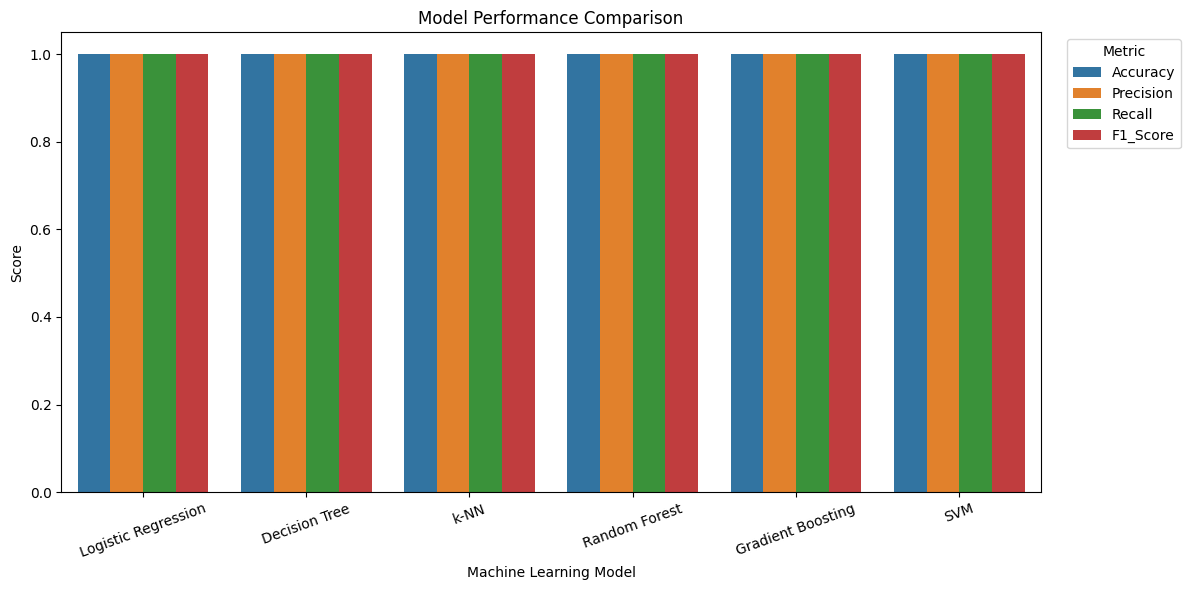

In [15]:
# Model comparison figure
plot_df = results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1_Score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_df,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Performance Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.savefig("figures/model_performance_comparison.pdf", bbox_inches="tight")
plt.show()


# 10. Best Model Selection

In [16]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_pred = predictions[best_model_name]

print("Best model based on F1-score:", best_model_name)

print("\nClassification Report:")
print(classification_report(y_test, best_pred, zero_division=0))

classification_report_df = pd.DataFrame(
    classification_report(y_test, best_pred, output_dict=True, zero_division=0)
).T

display(classification_report_df)

classification_report_df.to_csv("tables/best_model_classification_report.csv")

Best model based on F1-score: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       159
           1       1.00      1.00      1.00      1919

    accuracy                           1.00      2078
   macro avg       1.00      1.00      1.00      2078
weighted avg       1.00      1.00      1.00      2078



,precision,recall,f1-score,support
0,1.0,1.0,1.0,159.0
1,1.0,1.0,1.0,1919.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,2078.0
weighted avg,1.0,1.0,1.0,2078.0


,0,1
0,159,0
1,0,1919


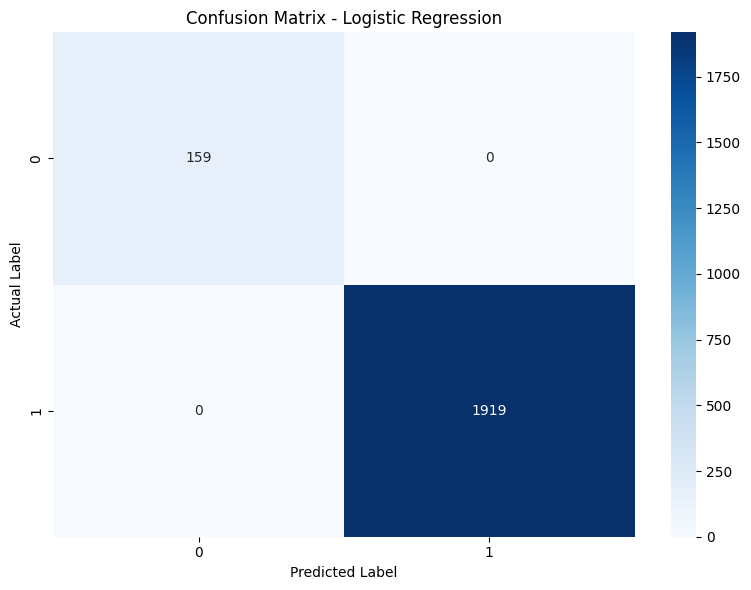

In [17]:
# Confusion matrix
cm = confusion_matrix(y_test, best_pred)

cm_df = pd.DataFrame(cm)

display(cm_df)

cm_df.to_csv("tables/best_model_confusion_matrix.csv", index=False)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()

plt.savefig("figures/best_model_confusion_matrix.pdf")
plt.show()


# 11. Feature Importance

,Feature,Importance
9,Stock_Marktet,0.202569
2,Mutual_Funds,0.097085
8,Gold,0.092990
21,Reason_FD,0.092313
4,Debentures,0.092295
7,PPF,0.064569
3,Equity_Market,0.061676
5,Government_Bonds,0.049030
22,Source,0.033346
6,Fixed_Deposits,0.032675


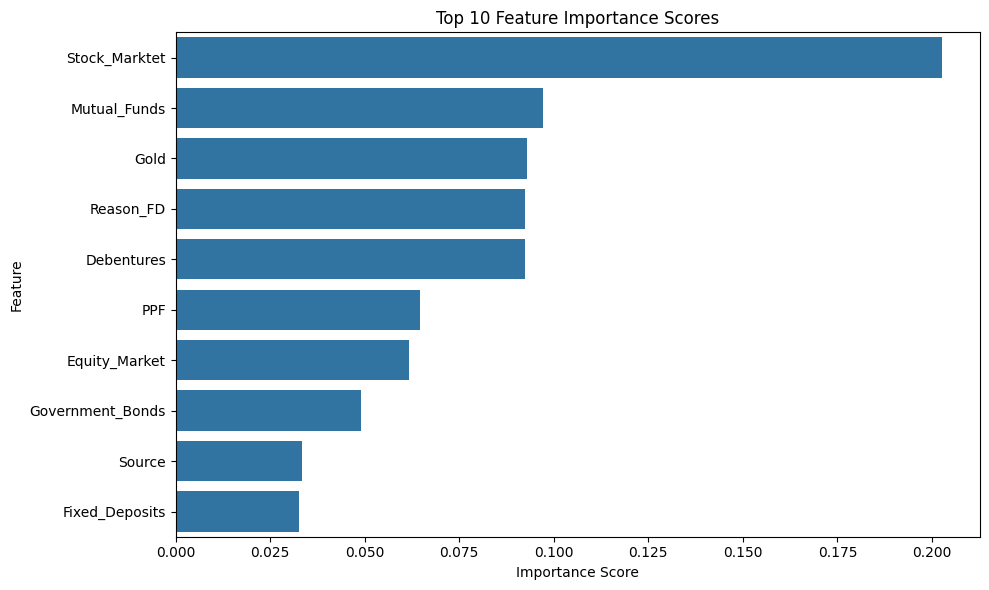

In [18]:
# Feature importance using Random Forest for interpretability
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE
)

rf_model.fit(X_train, y_train)

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance_df.head(15))

feature_importance_df.to_csv("tables/feature_importance.csv", index=False)

top_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance Scores")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig("figures/feature_importance_top10.pdf", bbox_inches="tight")
plt.show()


# 12. Cross-Validation

,Model,Mean_F1,Std_F1
0,Logistic Regression,1.0,0.0
1,Decision Tree,1.0,0.0
2,k-NN,1.0,0.0
3,Random Forest,1.0,0.0
4,Gradient Boosting,1.0,0.0
5,SVM,1.0,0.0


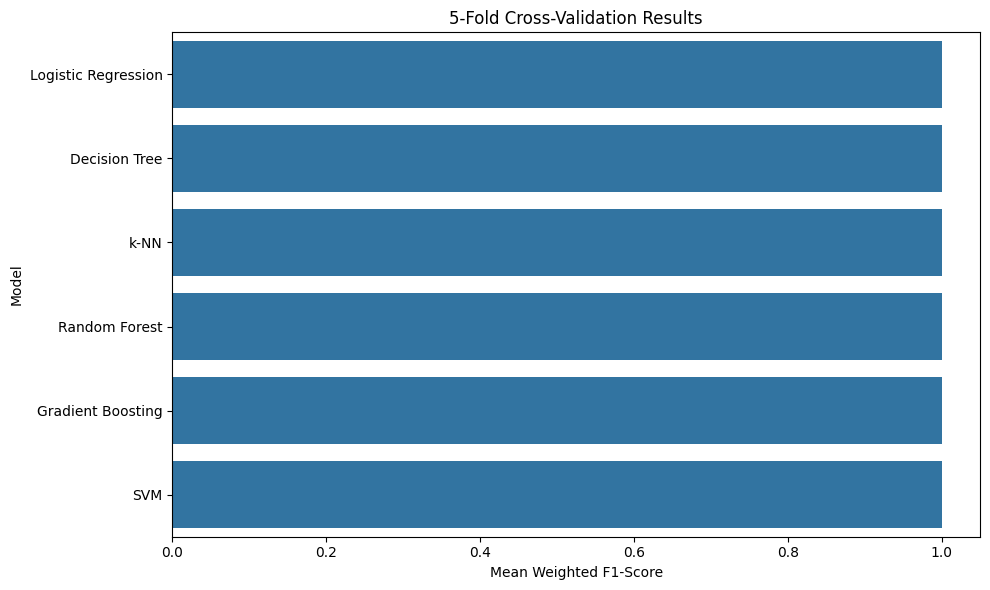

In [20]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="f1_weighted"
    )

    cv_results.append({
        "Model": name,
        "Mean_F1": scores.mean(),
        "Std_F1": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("Mean_F1", ascending=False)

display(cv_results_df)

cv_results_df.to_csv("tables/cross_validation_results.csv", index=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=cv_results_df,
    y="Model",
    x="Mean_F1"
)

plt.title("5-Fold Cross-Validation Results")
plt.xlabel("Mean Weighted F1-Score")
plt.ylabel("Model")
plt.xlim(0, 1.05)
plt.tight_layout()

plt.savefig("figures/cross_validation_results.pdf", bbox_inches="tight")
plt.show()


# 13. Robustness Test Using Label Noise

,Label_Noise_Level,Accuracy,Precision,Recall,F1_Score
0,0.00,1.000000,1.000000,1.000000,1.000000
1,0.05,0.998075,0.998122,0.998075,0.998086
2,0.10,0.989894,0.990629,0.989894,0.990102
3,0.15,0.969201,0.976664,0.969201,0.971279
4,0.20,0.943696,0.964774,0.943696,0.949892
5,0.30,0.867661,0.945473,0.867661,0.892399
6,0.40,0.709817,0.913172,0.709817,0.777266


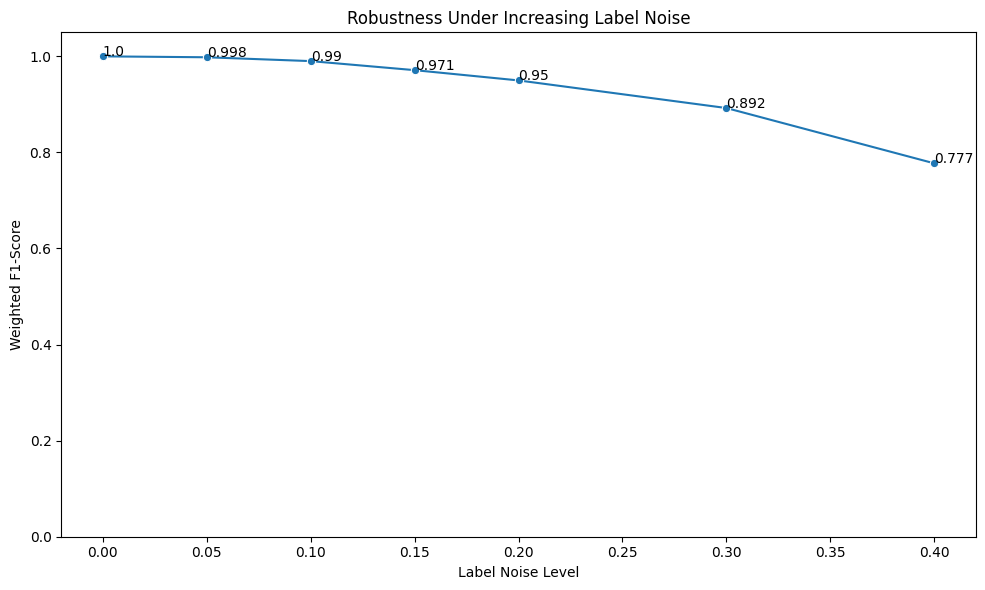

In [21]:
label_noise_levels = [0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

robustness_rows = []

for noise in label_noise_levels:
    y_train_noisy = y_train.copy()

    n_noise = int(len(y_train_noisy) * noise)

    if n_noise > 0:
        np.random.seed(RANDOM_STATE)

        noise_indices = np.random.choice(
            y_train_noisy.index,
            size=n_noise,
            replace=False
        )

        unique_classes = y_train_noisy.unique()

        for idx in noise_indices:
            current_label = y_train_noisy.loc[idx]

            possible_labels = [
                label for label in unique_classes
                if label != current_label
            ]

            y_train_noisy.loc[idx] = np.random.choice(possible_labels)

    model = RandomForestClassifier(random_state=RANDOM_STATE)

    model.fit(X_train, y_train_noisy)

    pred = model.predict(X_test)

    robustness_rows.append({
        "Label_Noise_Level": noise,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, pred, average="weighted", zero_division=0),
        "F1_Score": f1_score(y_test, pred, average="weighted", zero_division=0)
    })

robustness_df = pd.DataFrame(robustness_rows)

display(robustness_df)

robustness_df.to_csv("tables/label_noise_robustness.csv", index=False)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=robustness_df,
    x="Label_Noise_Level",
    y="F1_Score",
    marker="o"
)

plt.title("Robustness Under Increasing Label Noise")
plt.xlabel("Label Noise Level")
plt.ylabel("Weighted F1-Score")
plt.ylim(0, 1.05)

for i in range(len(robustness_df)):
    plt.text(
        robustness_df["Label_Noise_Level"][i],
        robustness_df["F1_Score"][i],
        round(robustness_df["F1_Score"][i], 3)
    )

plt.tight_layout()

plt.savefig("figures/label_noise_robustness.pdf")
plt.show()


# 14. Final Decision Matrix

,Criterion,Logistic Regression,Decision Tree,Random Forest,Gradient Boosting,SVM
0,Predictive Performance,3,3,5,5,4
1,Interpretability,5,4,3,2,2
2,Robustness,3,3,5,4,3
3,Computational Efficiency,5,5,3,3,2
4,Deployment Suitability,5,4,4,3,3


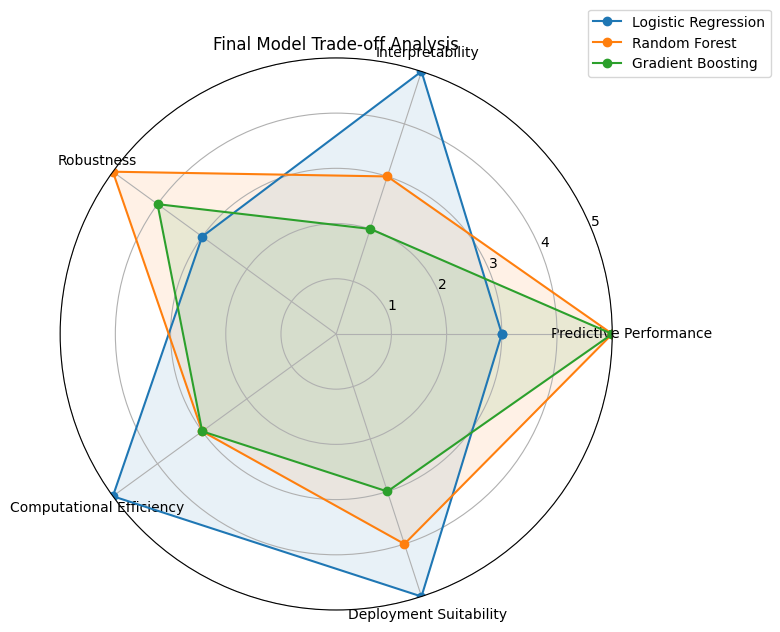

In [22]:
decision_df = pd.DataFrame({
    "Criterion": [
        "Predictive Performance",
        "Interpretability",
        "Robustness",
        "Computational Efficiency",
        "Deployment Suitability"
    ],
    "Logistic Regression": [3, 5, 3, 5, 5],
    "Decision Tree": [3, 4, 3, 5, 4],
    "Random Forest": [5, 3, 5, 3, 4],
    "Gradient Boosting": [5, 2, 4, 3, 3],
    "SVM": [4, 2, 3, 2, 3]
})

display(decision_df)

decision_df.to_csv("tables/final_decision_matrix.csv", index=False)

labels = decision_df["Criterion"].tolist()
model_names = ["Logistic Regression", "Random Forest", "Gradient Boosting"]

angles = np.linspace(
    0,
    2 * np.pi,
    len(labels),
    endpoint=False
).tolist()

angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw=dict(polar=True)
)

for model_name in model_names:
    values = decision_df[model_name].tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        marker="o",
        label=model_name
    )

    ax.fill(
        angles,
        values,
        alpha=0.10
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 5)

plt.title("Final Model Trade-off Analysis")
plt.legend(loc="upper right", bbox_to_anchor=(1.30, 1.10))
plt.tight_layout()

plt.savefig("figures/final_decision_radar_chart.pdf", bbox_inches="tight")
plt.show()

# 15. Final Conclusion

This notebook implemented a complete supervised learning workflow for predicting investment avenues using the Finance Trends 2020–2025 dataset.

The analysis included:

* dataset loading and cleaning,
* exploratory data analysis,
* categorical encoding,
* train-test splitting,
* training multiple supervised learning models,
* model comparison using Accuracy, Precision, Recall, and F1-score,
* best model selection,
* confusion matrix analysis,
* feature importance analysis,
* cross-validation,
* robustness analysis using label noise,
* and a final practical decision matrix.


Based on the evaluation metrics and practical model comparison, ensemble-based models such as Random Forest and Gradient Boosting are strong candidates for predicting investment avenues. Random Forest is especially useful because it provides strong performance, robustness, and interpretable feature importance.